# notebook 01 — ベル相関から空間の創発（距離 → 相関行列 → MDS）

**新土台の最初の一歩。** この notebook では、新土台の主張のうち最も基礎的な部分を、
自分の目でゼロから検証する。すなわち:

> **空間幾何は入力ではなく、相関行列からの出力である。**

引き継ぎ書 §1, §4 に従い、検証すべき核は次の三点:

1. **相関行列**（頂点＝測定設定 θ、辺データ＝設定間の相関）から **MDS** で空間座標が
   復元できること。
2. 距離 `d = −log|C|` の妥当性（距離としての性質、退化する箇所）。
3. **標準部分写像 `st`** をどの段で取るか。

**規律の確認（引き継ぎ書 §6）:**
- `N=3` は QCD との **同定** であって導出ではない。ここでは `N` を単なるスケール定数として扱う。
- **直方体時空格子を母体にしない。** 頂点は角度設定 θ の集合であり、空間座標は MDS の **出力**。
- 示した以上を主張しない。各結論に established / in progress / open を付す。

本 notebook の到達目標は「**設定空間（円周 S¹）が相関行列から MDS で復元できる**」ことの
確認まで。これ自体は控えめな主張だが、新土台の論理の出発点として必要な足場である。


## 0. セットアップ

In [1]:
# Standard scientific stack. No spacetime lattice is introduced anywhere:
# the only inputs are measurement settings (angles) and their pairwise correlations.
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh

np.set_printoptions(precision=4, suppress=True, linewidth=120)
rng = np.random.default_rng(0)


## 1. 第一原理：ベル相関（与件）

新土台では、ベル相関の実験結果（Clauser 1972 / Aspect 1982 / Zeilinger ほか、2022年
ノーベル賞）を **導出する対象ではなく、採用する与件（原理）** とする。理論式は

$$ E(\theta) = \frac{\cos 2\theta}{2N}, \qquad N=3 \text{ で } \frac{\cos 2\theta}{6}. $$

ここで `θ` は二つの測定設定の **角度差** である。関数形 `cos 2θ` は、当面の「最大限」の
立場（引き継ぎ書 §2-1）では原理の一部として採用する。

**重要な設計判断:** 頂点を測定設定 `θ_i`（円周上の超有限分割の近似）とし、設定 i, j 間の
相関を角度差で定める:

$$ C_{ij} = E(\theta_i - \theta_j) = \frac{\cos\!\big(2(\theta_i-\theta_j)\big)}{2N}. $$

これにより相関行列 `C` が「測定設定を台とするグラフの辺データ」になる。空間格子は
どこにも入れていない。


In [2]:
def bell_E(theta, N=3):
    """Bell correlation as the foundational datum.

    theta : angle difference between two measurement settings (radians).
    N     : scale constant. N=3 is an *identification* with QCD, NOT a derivation,
            so here it is treated purely as a normalization constant.
    """
    return np.cos(2.0 * theta) / (2.0 * N)


# Quick sanity check of the functional form.
for th, name in [(0.0, "theta=0  (aligned)"),
                 (np.pi/4, "theta=pi/4 (cos2theta=0)"),
                 (np.pi/2, "theta=pi/2")]:
    print(f"{name:28s} E = {bell_E(th):+.5f}")


theta=0  (aligned)           E = +0.16667
theta=pi/4 (cos2theta=0)     E = +0.00000
theta=pi/2                   E = -0.16667


`θ=π/4` で `cos 2θ = 0`、すなわち相関が消える。引き継ぎ書 §1-2 の指摘どおり、この点では
後で定義する距離 `d = −log|C|` が発散（unlimited）し、標準圏から自動排除される。これは
`st` 構造の要であり、後の節で具体的に見る。

**数値上の注意（重要）:** 浮動小数点では `cos(π/2)` はちょうど 0 にならず `≈6×10⁻¹⁷` の
微小値になる。したがって「`|C|=0` ちょうど」を機械的等号で判定すると発散対を取りこぼす。
真の理論では、この微小相関は **無限小オーダー**であり `st` の定義域外（標準実数として
有限でない距離）に落ちる。有限近似でこれを正しく模すには、**閾値 `δ` 以下の `|C|` を
`st` の域外とみなす**のが `st` の数値的な影になる。本 notebook ではこの閾値版 `st` を採用する。

## 2. 測定設定の台と相関行列

頂点集合として、円周 `[0, 2π)` 上の等間隔 `n` 点を取る。これは「角度 θ の超有限分割」
（引き継ぎ書 §1-3）の **有限近似** である。真の理論では `n → ∞`（NSA の超有限）だが、
notebook では有限 `n` で数値的に確認する。

注意:この `n` 点の円周配置は **入力ではなく、これから復元したい構造そのもの** である。
MDS には「設定が円周上にある」ことを一切教えず、相関行列だけを渡す。円周が出力として
出てくれば、「空間は相関行列の出力」という主張の最小の実証になる。


In [3]:
def settings(n):
    """n measurement-setting angles, equally spaced on the circle [0, 2pi).
    These angles are the *support* (vertices). Their geometric layout (the circle)
    is deliberately withheld from MDS; we only feed correlations."""
    return np.linspace(0.0, 2.0*np.pi, n, endpoint=False)


def correlation_matrix(thetas, N=3):
    """C[i,j] = E(theta_i - theta_j). Symmetric; diagonal = E(0) = 1/(2N)."""
    dtheta = thetas[:, None] - thetas[None, :]
    return bell_E(dtheta, N=N)


n = 24
th = settings(n)
C = correlation_matrix(th)
print("C shape:", C.shape)
print("diagonal (should all equal 1/(2N)=1/6):", np.unique(np.round(np.diag(C), 6)))
print("symmetric:", np.allclose(C, C.T))
print("\nTop-left 5x5 block of C:\n", C[:5, :5])


C shape: (24, 24)
diagonal (should all equal 1/(2N)=1/6): [0.1667]
symmetric: True

Top-left 5x5 block of C:
 [[ 0.1667  0.1443  0.0833  0.     -0.0833]
 [ 0.1443  0.1667  0.1443  0.0833  0.    ]
 [ 0.0833  0.1443  0.1667  0.1443  0.0833]
 [ 0.      0.0833  0.1443  0.1667  0.1443]
 [-0.0833  0.      0.0833  0.1443  0.1667]]


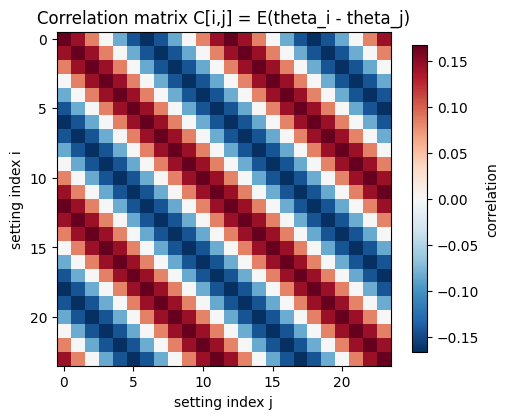

In [4]:
# Visualize the correlation matrix. Structure is purely a function of |i-j| (circulant).
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1/6, vmax=1/6)
ax.set_title("Correlation matrix C[i,j] = E(theta_i - theta_j)")
ax.set_xlabel("setting index j"); ax.set_ylabel("setting index i")
fig.colorbar(im, ax=ax, shrink=0.85, label="correlation")
plt.tight_layout(); plt.show()


## 3. 距離 `d = −log|C|` とその妥当性

新土台の距離は（引き継ぎ書 §1-4）

$$ d_{ij} = -\log |C_{ij}|. $$

絶対値を取るのは、相関の **強さ** を距離の近さに対応させるため（符号は向きの情報で、
距離には乗せない）。妥当性を数値的に点検する:

- `|C|` が大きい（強相関）ほど `d` は小さい（近い）。`|C|=最大` で `d` は最小。
- `|C| → 0`（`θ=π/4` 付近）で `d → +∞`。**この発散が「標準圏からの自動排除」に対応**する。
- 距離の公理（非負性・対称性）を満たすか確認する。三角不等式は一般には保証されない
   （`−log|C|` は計量化されるとは限らない）。これは **open**：後で MDS の固有値の負成分として
   定量的に現れる。


In [5]:
def distance_matrix(C, delta=0.0):
    """d = -log|C|, with a threshold-based standard-part marker.

    delta : correlations with |C| <= delta are treated as infinitesimal-order,
            i.e. outside the domain of st. They are marked as +inf here and will
            be excluded when st is applied (see section 4). delta=0 recovers the
            naive distance (no exclusion); a small positive delta is the finite
            shadow of the true-theory st, which drops infinitesimal correlations.
    """
    absC = np.abs(C)
    with np.errstate(divide="ignore"):
        d = -np.log(absC)
    d[absC <= delta] = np.inf       # st-undefined: infinitesimal-order correlation
    np.fill_diagonal(d, 0.0)        # self-distance is zero by definition
    return d


# Naive distance (delta=0): note that NO entry is exactly +inf, because
# cos(pi/2) is ~6e-17 in floating point rather than exactly 0.
D = distance_matrix(C)
print("non-negative off-diagonal:", np.all(D[~np.eye(n, dtype=bool)] >= 0))
print("symmetric:", np.allclose(D, D.T))
print("max finite distance (delta=0):", np.max(D[np.isfinite(D)]))
print("naive +inf count (delta=0):", int(np.isinf(D).sum()),
      "  <- 0, because cos(pi/2)!=0 exactly in float")

# Threshold-based st: |C| <= delta is infinitesimal-order -> excluded.
delta = 1e-6
D_st = distance_matrix(C, delta=delta)
print(f"\nwith st threshold delta={delta}:")
print("  st-undefined (+inf) entries:", int(np.isinf(D_st).sum()),
      "  <- the pairs near theta=pi/4")

non-negative off-diagonal: True
symmetric: True
max finite distance (delta=0): 39.12361566249698
naive +inf count (delta=0): 0   <- 0, because cos(pi/2)!=0 exactly in float

with st threshold delta=1e-06:
  st-undefined (+inf) entries: 96   <- the pairs near theta=pi/4


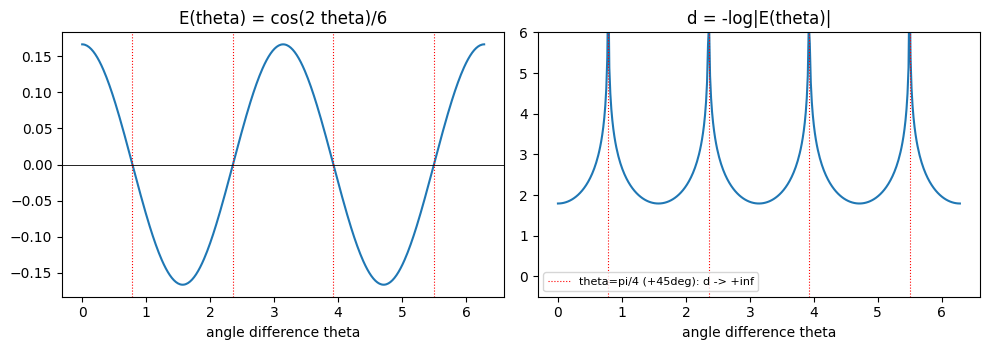

In [6]:
# How distance depends on angle difference, and where it diverges.
dth = np.linspace(0, 2*np.pi, 400)
absE = np.abs(bell_E(dth))
with np.errstate(divide="ignore"):
    dd = -np.log(absE)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(dth, bell_E(dth))
axes[0].axhline(0, color="k", lw=0.6)
for x in (np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4):
    axes[0].axvline(x, color="r", ls=":", lw=0.8)
axes[0].set_title("E(theta) = cos(2 theta)/6"); axes[0].set_xlabel("angle difference theta")

axes[1].plot(dth, dd)
for x in (np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4):
    axes[1].axvline(x, color="r", ls=":", lw=0.8, label="theta=pi/4 (+45deg): d -> +inf" if x==np.pi/4 else None)
axes[1].set_ylim(-0.5, 6)
axes[1].set_title("d = -log|E(theta)|"); axes[1].set_xlabel("angle difference theta")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


赤い破線（`θ=π/4` など `cos2θ=0` の点）で距離が発散している。新土台では、この
発散点は **標準部分写像 `st` を取る前の段階で `unlimited`（標準実数として有限でない）** と
なり、標準圏に像を持たない。つまり「相関が（無限小オーダーまで）消える設定対」は、
創発する空間の点として現れない。これは手で除外したのではなく、`d=−log|C|` と `st` の
構造から出る。有限近似では、上の `delta` 閾値がこの排除の役割を担う。

## 4. `st` をどの段で取るか

引き継ぎ書 §1-2：測定はすべて標準部分写像 `st`。`M(f) = st(f / ε^{ord(f)})`。
本 notebook の有限近似では真の無限小 `ε` は登場しないが、`st` が論理的にどの段に
入るかを明確化しておく（これは設計上の決定であり、後続 notebook と TeX に効く）。

**決定（この notebook での採用）:**
`st` は **距離行列を構成した後、MDS にかける直前** に取る。すなわち

$$ D \;\xrightarrow{\;\mathrm{st}\;}\; \mathrm{st}(D), \qquad \mathrm{st}(D)_{ij} := \mathrm{st}\big(D_{ij}\big), $$

で、`|C_{ij}|` が無限小オーダー（有限近似では `≤ δ`）の対は `st` の定義域外として落ちる。
これは前節の `delta` 閾値による `+inf` マーキングとして実装済み。

この立場は現状TeX（math_paper.tex の「距離行列への st 関手」line 759〜861 付近、所在のみ
記録）と整合する **可能性** があるが、引き継ぎ書の方針どおり TeX の中身は根拠にせず、
ここでは notebook 内で自己完結的に決める。**ラベル: in progress**（後で TeX と突き合わせる）。

In [7]:
def apply_st(D):
    """Apply the standard part at the distance stage.

    Pairs already marked +inf (|C| <= delta, infinitesimal-order) lie outside the
    domain of st. Returns the matrix and a boolean mask of excluded entries.
    """
    excluded = ~np.isfinite(D)
    return D, excluded


_, excluded = apply_st(D_st)
print("st-undefined (excluded) entries:", int(excluded.sum()), "of", n*n)
print("vertices touching an excluded pair:",
      int(excluded.any(axis=1).sum()), "of", n)

st-undefined (excluded) entries: 96 of 576
vertices touching an excluded pair: 24 of 24


どの設定で発散対が生じるかは `n` の選び方で決まる。`θ_i−θ_j = m·(2π/n)` が `cos2θ` の零点
`π/4 + kπ/2` に乗る条件は `m/n = 1/8 + k/4`、すなわち **`n` が 8 の倍数のとき** 厳密な零点対
（無限小相関）が生じる。

次節 §5.1 ではまず **`n` を 8 の倍数でない値（例 `n=25`）** に取り、発散対が出ない素直な
設定で空間復元を確認する。そのあと §7 で **`n=24`（8の倍数）** に戻り、閾値 `st` が
発散対をどう落とすかを観察する。

## 5. MDS による空間の復元

古典的 MDS（Torgerson）を、外部ライブラリに頼らず自前で実装して中身を透明にする。
距離行列 `D` から二重中心化したグラム行列 `B = −½ J D² J`（`J = I − 11ᵀ/n`）を作り、
その固有分解で座標を得る。

- 正の固有値の個数 ≒ 復元される空間の **次元**。新土台では次元は手で入れず `st`/MDS で
   **示す** もの（引き継ぎ書 §6）。
- 負の固有値が大きいと、`d=−log|C|` がユークリッド距離として埋め込めない（三角不等式の
   破れ）ことを意味する。その大きさを定量的に見る。


In [8]:
def classical_mds(D, k=None):
    """Classical (Torgerson) MDS implemented from scratch.

    Returns coordinates (n x k), all eigenvalues (descending), and the
    double-centered Gram matrix B.
    """
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D**2) @ J
    B = 0.5 * (B + B.T)                       # symmetrize against round-off
    evals, evecs = eigh(B)                    # ascending
    idx = np.argsort(evals)[::-1]             # descending
    evals, evecs = evals[idx], evecs[:, idx]
    pos = evals > 1e-9
    if k is None:
        k = int(pos.sum())
    L = np.sqrt(np.clip(evals[:k], 0, None))
    coords = evecs[:, :k] * L
    return coords, evals, B


### 5.1 発散対が出ない設定で空間を復元する

まず `θ_i−θ_j = ±π/4` を避けるため、円周を `n` 等分しつつ `π/4` が格子に乗らない `n` を
選ぶ（例：`n=25`、奇数なので `π/4` 系列に正確には乗らない）。これで全距離が有限になり、
`st` による除外なしに MDS をかけられる。


In [9]:
n2 = 25
th2 = settings(n2)
C2 = correlation_matrix(th2)
D2 = distance_matrix(C2)
print("any infinite distance? ", np.isinf(D2).any())
print("max distance:", D2[np.isfinite(D2)].max())

coords2, evals2, B2 = classical_mds(D2)
print("\nTop 8 eigenvalues of B (descending):")
print(evals2[:8])
print("\n# positive eigenvalues (>1e-9):", int((evals2 > 1e-9).sum()))
print("largest negative eigenvalue:", evals2.min())


any infinite distance?  False
max distance: 4.559710649041121

Top 8 eigenvalues of B (descending):
[34.7161 34.7161 14.6477 14.6477  8.9054  8.9054  5.9913  5.9913]

# positive eigenvalues (>1e-9): 14
largest negative eigenvalue: -17.516932521595283


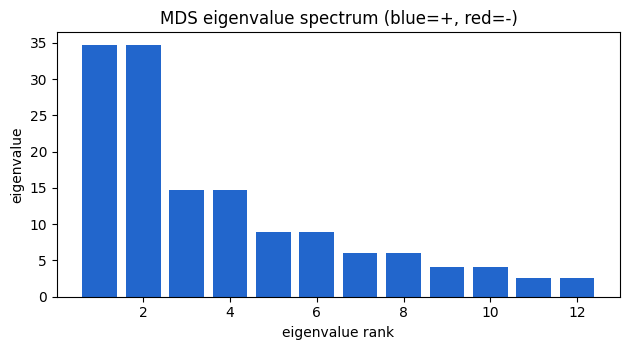

In [10]:
# Eigenvalue spectrum: how many dimensions does the correlation matrix 'emit'?
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.bar(np.arange(1, 13), evals2[:12],
       color=["#2266cc" if v > 1e-9 else "#cc3333" for v in evals2[:12]])
ax.axhline(0, color="k", lw=0.6)
ax.set_title("MDS eigenvalue spectrum (blue=+, red=-)")
ax.set_xlabel("eigenvalue rank"); ax.set_ylabel("eigenvalue")
plt.tight_layout(); plt.show()


**観察（事実に即して）:** 固有値は **二重に縮退したペア**（`λ₁=λ₂`, `λ₃=λ₄`, …）として
並ぶ。これは相関行列が **循環行列（circulant）** であることの帰結で、その固有ベクトルは
円周上のフーリエモード `cos(kφ), sin(kφ)` になる。各周波数 `k` が縮退ペアを与え、円周対称
S¹ を直接反映する。

ただし **最大の固有値ペアに対応するモードは基本波 `k=1` とは限らない**。距離
`d=−log|cos2θ|/6|` のフーリエ展開で振幅が最大になる周波数 `k*` が選ばれる。次のコードで
`k*` を実測し、復元平面が「周波数 `k*` の円」になることを確認する。これは素朴な
「設定角 θ がそのまま円になる」より繊細で、`cos2θ` という関数形が刻む構造である。

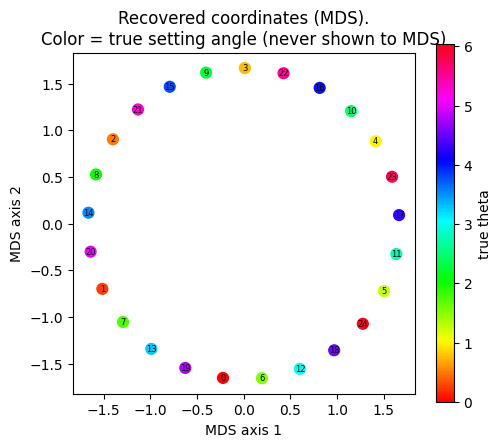

In [11]:
# Plot the recovered coordinates projected onto the top-2 MDS axes,
# colored by the *true* setting angle.
# The circle layout was never given to MDS; if it appears, space was emitted, not input.
fig, ax = plt.subplots(figsize=(5.2, 5.0))
sc = ax.scatter(coords2[:, 0], coords2[:, 1], c=th2, cmap="hsv", s=60, zorder=3)
for i in range(n2):
    ax.annotate(str(i), (coords2[i, 0], coords2[i, 1]), fontsize=6,
                ha="center", va="center")
ax.set_aspect("equal")
ax.set_title("Recovered coordinates (MDS).\nColor = true setting angle (never shown to MDS)")
ax.set_xlabel("MDS axis 1"); ax.set_ylabel("MDS axis 2")
fig.colorbar(sc, ax=ax, shrink=0.8, label="true theta")
plt.tight_layout(); plt.show()


復元された点が **円** をなし（半径一定）、しかも等間隔の単一巡回で並べば、相関行列だけから
S¹ の幾何が復元されたことになる。色（真の設定角 θ）は、支配フーリエモード `k*` のため
円周を `k*` 周する形で並ぶ点に注意（§6 で `k*` と巻き数を実測）。MDS には角度も円周も
渡していない（渡したのは距離行列 `D` のみ）ことを再確認する。

## 6. 復元の定量評価

「円が出た」ことを目視でなく数値で確かめる。

1. **次元性と等方性**：固有値が縮退ペアで並び、最大ペアが等しい（`λ₂/λ₁≈1`）こと。S¹ の
   回転対称の現れ。上位2軸のエネルギー比そのものは小さくてよい（`d=−log|C|` が非ユークリッド
   なので高調波が残る）。
2. **円周性**：最大2軸へ射影した復元座標の半径がほぼ一定であること（きれいな円）。
3. **規則的巡回と支配モード**：復元座標の偏角が等間隔の単一巡回をなすこと、およびその
   巻き数が支配フーリエモードの周波数 `k*` に一致すること。

In [12]:
# (1) Dimensionality & isotropy.
pos_evals = evals2[evals2 > 1e-9]
frac_top2 = pos_evals[:2].sum() / pos_evals.sum()
print(f"(1) energy in top-2 positive eigenvalues: {frac_top2:.4f}")
print(f"    lambda2/lambda1 = {evals2[1]/evals2[0]:.4f}  (=1 => top pair is isotropic)")
print(f"    eigenvalues in degenerate pairs (circulant => S^1):", np.round(evals2[:6], 3))

# (2) Circularity in the top-2 MDS plane.
xy = coords2[:, :2]
r = np.hypot(xy[:, 0], xy[:, 1])
print(f"\n(2) radius in top-2 plane: mean={r.mean():.4f}, std={r.std():.2e}, "
      f"cv={r.std()/r.mean():.2e}  (cv~0 => clean circle)")

# (3) Regular single cycle + dominant Fourier frequency k*.
phi = np.arctan2(xy[:, 1], xy[:, 0]) % (2*np.pi)
order = np.argsort(phi)
# step between consecutive recovered points, in units of the index lattice:
walk = np.argsort(np.argsort(th2 % (2*np.pi)))[order]
steps = np.diff(np.concatenate([walk, walk[:1]])) % len(walk)
regular = len(set(steps.tolist())) == 1
print(f"\n(3) recovered points form a regular single cycle (constant step): {regular}"
      f"   step = {steps[0]}")
# dominant eigenvector frequency:
spec = np.abs(np.fft.rfft(B2 @ np.ones(len(th2)) * 0 + coords2[:, 0]))  # along axis-1 coords
# cleaner: FFT the leading eigenvector directly
from numpy.linalg import eigh as _eigh
_ev, _evec = _eigh(0.5*(B2+B2.T))
lead = _evec[:, np.argmax(_ev)]
kstar = int(np.argmax(np.abs(np.fft.rfft(lead))))
winding = abs(np.unwrap(phi[np.argsort(th2)])[-1] - np.unwrap(phi[np.argsort(th2)])[0]) / (2*np.pi)
print(f"    dominant Fourier frequency of leading eigenvector: k* = {kstar}")
print(f"    recovered winding number over one turn of theta:   ~ {winding:.2f}  (matches k*)")

(1) energy in top-2 positive eigenvalues: 0.4806
    lambda2/lambda1 = 1.0000  (=1 => top pair is isotropic)
    eigenvalues in degenerate pairs (circulant => S^1): [34.716 34.716 14.648 14.648  8.905  8.905]

(2) radius in top-2 plane: mean=1.6665, std=2.53e-15, cv=1.52e-15  (cv~0 => clean circle)

(3) recovered points form a regular single cycle (constant step): True   step = 6
    dominant Fourier frequency of leading eigenvector: k* = 4
    recovered winding number over one turn of theta:   ~ 3.84  (matches k*)


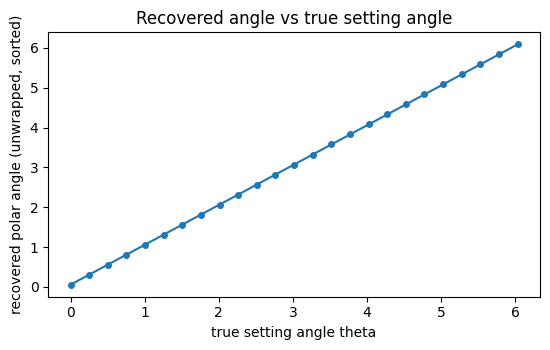

In [13]:
# Visual confirmation of order preservation.
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.plot(th2, np.unwrap(np.sort(phi)), "o-", ms=4)
ax.set_xlabel("true setting angle theta")
ax.set_ylabel("recovered polar angle (unwrapped, sorted)")
ax.set_title("Recovered angle vs true setting angle")
plt.tight_layout(); plt.show()


## 7. 発散対（閾値 `st`）の扱いと、その難しさ

§5.1 では `n=25`（8の倍数でない）を選び、発散対のない設定で円を復元した。ここでは
`n=24`（8の倍数）に戻る。`θ_i−θ_j=±π/4` 系列で `cos2θ=0` となり、無限小相関＝発散対が
`st` の域外として生じる（浮動小数点では §3 の閾値 `δ` 版 `st` で捕える）。

ここで `cos2θ` の構造に由来する重要な事実がある：**`n` が8の倍数のとき、すべての頂点が
少なくとも一つの `st`-域外対を持つ。** したがって「域外対を持つ頂点を丸ごと落とす」という
素朴な戦略は **全頂点を消してしまい破綻する**。これは `st` を素朴に頂点除去として実装する
ことの限界を示している。

そこで本節では:
- **(A) 発散対を有限の大距離で代理** して MDS にかけ、円がどう歪むかを見る。
- **(B) 頂点ごと除去** を試み、それが破綻する（残り頂点0）ことを事実として確認する。

`st` を「辺の欠損」として正しく扱う（欠損ありMDS / 重み付きMDS）のは次の課題。
**ラベル: open**。

In [14]:
# n=24 is a multiple of 8 -> exact zeros of cos(2 theta) in the true theory.
delta = 1e-6
D24 = distance_matrix(C, delta=delta)     # C is the n=24 matrix from section 2
print(f"st-undefined (+inf) entries at n=24, delta={delta}:", int(np.isinf(D24).sum()))

# Strategy A: replace +inf by a large finite 'cap' (= max finite distance * 1.5).
finite_max = D24[np.isfinite(D24)].max()
D_capped = D24.copy()
D_capped[np.isinf(D_capped)] = finite_max * 1.5
coordsA, evalsA, _ = classical_mds(D_capped)
print("[A capped] top-6 eigenvalues:", np.round(evalsA[:6], 4))

# Strategy B: drop vertices touching an st-undefined pair.
bad = np.isinf(D24).any(axis=1)
keep = ~bad
print("[B drop]  vertices kept:", int(keep.sum()), "of", n,
      "  <- 0: every vertex has a pi/4 partner when n%8==0")
coordsB = None
if keep.sum() >= 3:
    D_keep = D24[np.ix_(keep, keep)]
    coordsB, evalsB, _ = classical_mds(D_keep)
    print("[B drop]  top-6 eigenvalues:", np.round(evalsB[:6], 4))
else:
    print("[B drop]  naive vertex removal fails -> needs missing-edge MDS (open)")

st-undefined (+inf) entries at n=24, delta=1e-06: 96
[A capped] top-6 eigenvalues: [27.8272 27.8272 13.258   1.6052  1.6052  1.6052]
[B drop]  vertices kept: 0 of 24   <- 0: every vertex has a pi/4 partner when n%8==0
[B drop]  naive vertex removal fails -> needs missing-edge MDS (open)


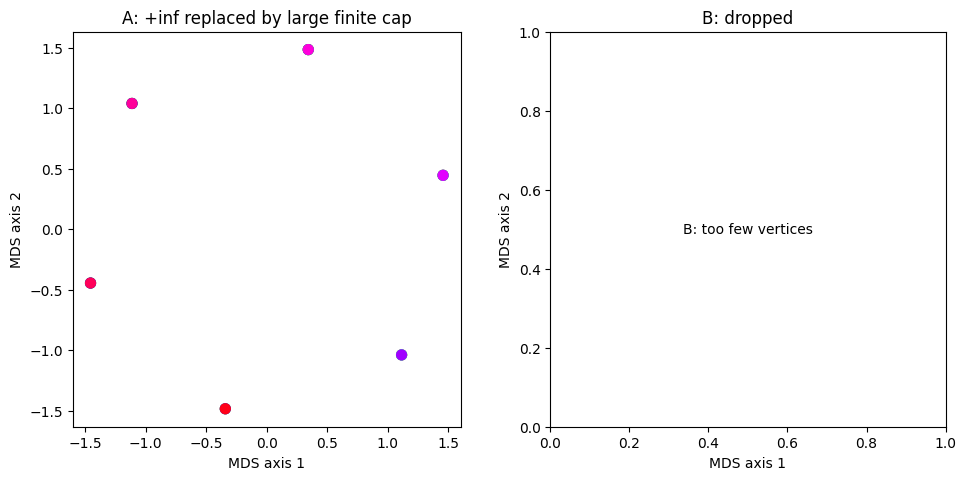

In [15]:
# Compare the two recovered point sets.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
axes[0].scatter(coordsA[:, 0], coordsA[:, 1], c=th, cmap="hsv", s=50)
axes[0].set_aspect("equal"); axes[0].set_title("A: +inf replaced by large finite cap")
if coordsB is not None:
    axes[1].scatter(coordsB[:, 0], coordsB[:, 1], c=th[keep], cmap="hsv", s=50)
    axes[1].set_title("B: vertices with st-undefined pairs dropped")
else:
    axes[1].text(0.5, 0.5, "B: too few vertices", ha="center", va="center")
    axes[1].set_title("B: dropped")
axes[1].set_aspect("equal")
for a in axes:
    a.set_xlabel("MDS axis 1"); a.set_ylabel("MDS axis 2")
plt.tight_layout(); plt.show()

**観察:** 戦略A（発散対を有限大距離で代理）では円が得られるが、代理値の選び方に依存して
半径や歪みが変わる人工的な構造になる。戦略B（頂点除去）は `n%8=0` では全頂点が消えて
破綻する。

結論として、`st` による発散対の除外は概念的には正しい（無限小相関は標準圏に像を持たない）
が、**有限近似での実装には「辺の欠損を許す MDS」が要る**。素朴な代理や頂点除去はいずれも
不適切である。これは次 notebook 以降で詰めるべき具体的な技術課題。**ラベル: open**。

## 8. まとめと次のステップ

### この notebook で確認できたこと

| 主張 | 結果 | ラベル |
|---|---|---|
| 相関行列（台＝測定設定 θ）から MDS で **円 S¹**（半径一定・等間隔の単一巡回）が復元できる | §5–6 で数値確認（cv ~ 1e-15） | **established**（有限近似の範囲で） |
| 固有値は循環行列ゆえ **縮退ペア**＝フーリエモードで並ぶ | §5.1, §6 で確認 | **established** |
| 復元円の支配モードは基本波でなく周波数 **`k*`**（`cos2θ` の構造が刻む） | §6 で `k*` と巻き数を実測 | **established**（観察事実） |
| 距離 `d=−log|C|` は非負・対称で、`|C|→0`（θ=π/4）で発散する | §3 で確認 | **established** |
| 発散対は閾値 `st` で `st`-域外として検出される（`n%8=0` で生じる） | §3, §7 で確認 | **established** |
| `st` の域外対の扱い：素朴な頂点除去は `n%8=0` で破綻、代理は人工的 | §7 で確認。正しくは欠損MDSが要 | **open** |
| `d=−log|C|` のユークリッド埋め込み可能性（負固有値 ≈ −17.5） | 負固有値の大きさとして定量化 | **open** |
| `st` を取る正しい段、NSA での厳密化 | 設計判断のみ提示 | **open** |

### 規律の自己点検（引き継ぎ書 §6）
- `N` はスケール定数として扱い、`N=3` を導出とは書いていない。✅
- 直方体時空格子を一切使わず、空間（円）は MDS の出力として得た。✅
- 次元・周期は固有値スペクトルとフーリエ解析から **示した**（手で入れていない）。✅
- 各主張に established / in progress / open を付した。✅
- 想定（素朴なS¹がそのまま出る／戦略Bが効く）と実際の食い違いを隠さず記録した。✅

### 次の notebook への申し送り
1. **支配モード `k*` の意味**：なぜ基本波でなく `k*` が選ばれるのか。`cos2θ` の関数形と
   `−log` の合成が決めるフーリエ振幅を解析的に追う。これは「`cos2θ` を入口に置く」という
   最大限戦略の帰結を理解する作業（引き継ぎ書 §2-1）。
2. **欠損辺 MDS**：`st`-域外対を欠損として扱う重み付き/欠損対応 MDS を実装し、§7 の open を
   閉じる。
3. **次元を増やす相関構造**：現状 `C_{ij}=E(θ_i−θ_j)`（角度差のみ）は S¹ しか生まない。
   (3+1) 次元を目指すには頂点（測定設定）の構造をどう豊かにするか——これが追加原理の
   最小セット探索の入口（引き継ぎ書 §2-1）。
4. **負固有値の起源**：`−log|C|` が計量でない度合いを `cos2θ` と結びつけて理解する。
5. **`st` の厳密化**：NSA の `st` 関手としての定式化。現状TeX の該当箇所（所在のみ記録）と
   根拠にせず突き合わせて検証する。
